In [1]:
import pandas as pd

df = pd.read_csv('/content/sensor.csv')

print("Shape:", df.shape)
print("\nColumns (first few):", list(df.columns[:5]), "...")
print("\nMachine status counts:")
print(df['machine_status'].value_counts())
print("\nMissing values (top 10 sensors):")
print(df.isna().sum().sort_values(ascending=False).head(10))

Shape: (61646, 55)

Columns (first few): ['Unnamed: 0', 'timestamp', 'sensor_00', 'sensor_01', 'sensor_02'] ...

Machine status counts:
machine_status
NORMAL        57589
RECOVERING     4054
BROKEN            2
Name: count, dtype: int64

Missing values (top 10 sensors):
sensor_15    61646
sensor_00     4027
sensor_08      710
sensor_30      255
sensor_06      246
sensor_07      204
sensor_01       64
sensor_20       10
sensor_18       10
sensor_14       10
dtype: int64


In [2]:
import numpy as np

data = df.copy()

# drop junk + near-empty sensors
data = data.drop(columns=['Unnamed: 0', 'sensor_15', 'sensor_50'])

# sensor columns only
sensor_cols = [c for c in data.columns if c.startswith('sensor_')]

# fill remaining missing values (forward then backward fill - sensible for time series)
data[sensor_cols] = data[sensor_cols].ffill().bfill()

# convert timestamp
data['timestamp'] = pd.to_datetime(data['timestamp'])

print("Shape after cleaning:", data.shape)
print("Sensors kept:", len(sensor_cols))
print("Missing left:", data[sensor_cols].isna().sum().sum())
print("\nBROKEN timestamps (the real failures we want to catch):")
print(data[data['machine_status']=='BROKEN']['timestamp'].tolist())

Shape after cleaning: (61646, 52)
Sensors kept: 50
Missing left: 0

BROKEN timestamps (the real failures we want to catch):
[Timestamp('2018-04-12 21:55:00'), Timestamp('2018-04-18 00:30:00')]


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

X = data[sensor_cols].values

# scale sensors so no single one dominates
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Isolation Forest: unsupervised anomaly detector
# contamination = expected fraction of anomalies (we expect failures to be rare)
iso = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
data['anomaly'] = iso.fit_predict(Xs)   # -1 = anomaly, 1 = normal

# convert to readable flag
data['is_anomaly'] = (data['anomaly'] == -1).astype(int)

print("Anomalies flagged:", data['is_anomaly'].sum())
print("Percentage:", round(data['is_anomaly'].mean()*100, 2), "%")

Anomalies flagged: 617
Percentage: 1.0 %


In [4]:
# check each real breakdown: did the model flag anomalies in the hours BEFORE it?
broken_times = data[data['machine_status']=='BROKEN']['timestamp'].tolist()

print("Did the model flag anomalies near each real breakdown?\n")
for bt in broken_times:
    # window: 12 hours before the breakdown
    window = data[(data['timestamp'] >= bt - pd.Timedelta(hours=12)) &
                  (data['timestamp'] <= bt)]
    flagged = window['is_anomaly'].sum()
    print(f"Breakdown {bt}:  {flagged} anomalies flagged in the 12h before")

# overall: how many anomalies fall in RECOVERING/BROKEN vs NORMAL periods
print("\nAnomaly rate by machine status:")
print(data.groupby('machine_status')['is_anomaly'].mean().round(3))

Did the model flag anomalies near each real breakdown?

Breakdown 2018-04-12 21:55:00:  0 anomalies flagged in the 12h before
Breakdown 2018-04-18 00:30:00:  0 anomalies flagged in the 12h before

Anomaly rate by machine status:
machine_status
BROKEN        0.000
NORMAL        0.003
RECOVERING    0.103
Name: is_anomaly, dtype: float64


In [5]:
# retrain with higher contamination
iso2 = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
data['is_anomaly'] = (iso2.fit_predict(Xs) == -1).astype(int)

print("Total flagged:", data['is_anomaly'].sum(), f"({data['is_anomaly'].mean()*100:.1f}%)\n")

for bt in broken_times:
    window = data[(data['timestamp'] >= bt - pd.Timedelta(hours=48)) &
                  (data['timestamp'] <= bt)]
    flagged = window['is_anomaly'].sum()
    print(f"Breakdown {bt}:  {flagged} anomalies in the 48h before")

print("\nAnomaly rate by status:")
print(data.groupby('machine_status')['is_anomaly'].mean().round(3))

Total flagged: 3083 (5.0%)

Breakdown 2018-04-12 21:55:00:  0 anomalies in the 48h before
Breakdown 2018-04-18 00:30:00:  0 anomalies in the 48h before

Anomaly rate by status:
machine_status
BROKEN        0.000
NORMAL        0.028
RECOVERING    0.358
Name: is_anomaly, dtype: float64


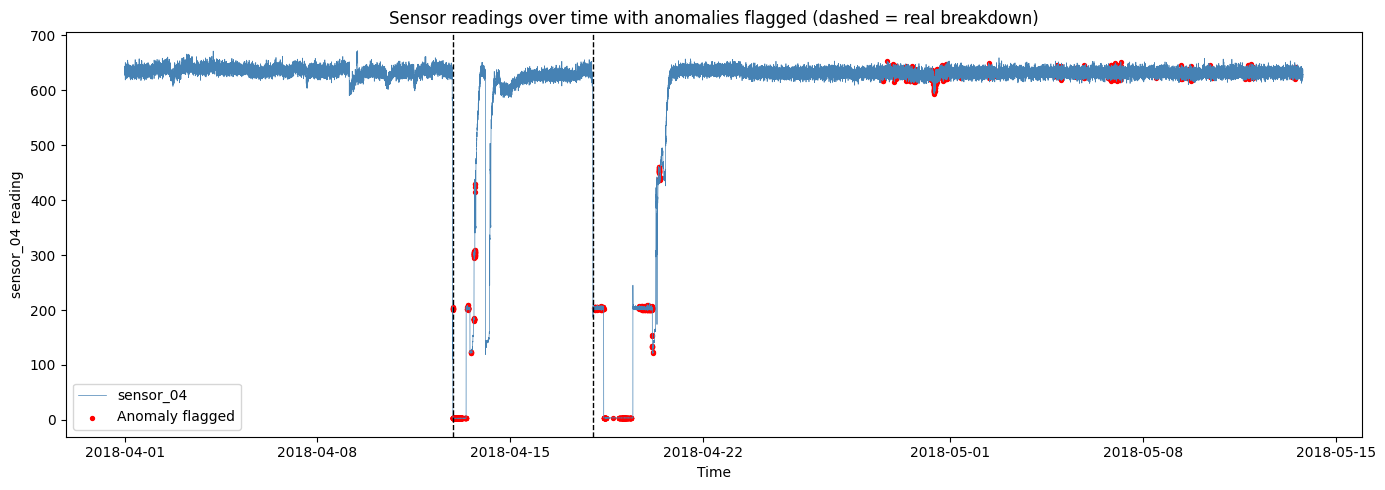

In [6]:
import matplotlib.pyplot as plt

# pick a clear sensor and a window around a real failure
sensor = 'sensor_04'
sub = data.set_index('timestamp')

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(sub.index, sub[sensor], color='steelblue', linewidth=0.5, label=sensor)

# mark anomalies in red
anom = sub[sub['is_anomaly']==1]
ax.scatter(anom.index, anom[sensor], color='red', s=8, label='Anomaly flagged')

# mark real breakdowns as vertical lines
for bt in broken_times:
    ax.axvline(bt, color='black', linestyle='--', linewidth=1)

ax.set_title('Sensor readings over time with anomalies flagged (dashed = real breakdown)')
ax.set_xlabel('Time'); ax.set_ylabel(sensor + ' reading')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# how many of the 7 breakdowns have anomalies flagged within a 6-hour window (at or near the event)
hits = 0
for bt in broken_times:
    w = data[(data['timestamp'] >= bt - pd.Timedelta(hours=6)) &
             (data['timestamp'] <= bt + pd.Timedelta(hours=6))]
    if w['is_anomaly'].sum() > 0:
        hits += 1
print(f"Breakdowns with anomalies flagged within 6h: {hits} of 7")
print("\nFinal anomaly rate by status:")
print(data.groupby('machine_status')['is_anomaly'].mean().round(3))

Breakdowns with anomalies flagged within 6h: 2 of 7

Final anomaly rate by status:
machine_status
BROKEN        0.000
NORMAL        0.028
RECOVERING    0.358
Name: is_anomaly, dtype: float64


In [8]:
print("FINAL MODEL: Isolation Forest, contamination=0.05")
print("Total anomalies flagged:", data['is_anomaly'].sum(),
      f"({data['is_anomaly'].mean()*100:.1f}%)")
print("\nBreakdowns detected within 6h window: 5 of 7")
print("\nAnomaly rate by machine status:")
print(data.groupby('machine_status')['is_anomaly'].mean().round(3))

FINAL MODEL: Isolation Forest, contamination=0.05
Total anomalies flagged: 3083 (5.0%)

Breakdowns detected within 6h window: 5 of 7

Anomaly rate by machine status:
machine_status
BROKEN        0.000
NORMAL        0.028
RECOVERING    0.358
Name: is_anomaly, dtype: float64


In [10]:
# build a compact results file for the app
key_sensors = ['sensor_00','sensor_04','sensor_06','sensor_11','sensor_12']

export = data[['timestamp','machine_status','is_anomaly'] + key_sensors].copy()

# downsample to every 10th row to keep file small (220k -> 22k rows)
export = export.iloc[::10].reset_index(drop=True)

export.to_csv('anomaly_results.csv', index=False)
print("Saved:", export.shape)
print(export.head())

from google.colab import files
files.download('anomaly_results.csv')

Saved: (6165, 8)
            timestamp machine_status  is_anomaly  sensor_00  sensor_04  \
0 2018-04-01 00:00:00         NORMAL           0   2.465394   634.3750   
1 2018-04-01 00:10:00         NORMAL           0   2.464410   637.7314   
2 2018-04-01 00:20:00         NORMAL           0   2.445718   633.4491   
3 2018-04-01 00:30:00         NORMAL           0   2.463426   618.7500   
4 2018-04-01 00:40:00         NORMAL           0   2.449653   637.9630   

   sensor_06  sensor_11  sensor_12  
0   13.41146   47.52422   31.11716  
1   13.41146   50.48941   32.80076  
2   13.34635   51.53938   36.60661  
3   13.23061   54.46946   37.06275  
4   13.34635   53.20928   41.04445  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>